In [1]:
import pandas as pd
#load the dataset
df = pd.read_csv("/content/Titanic-Dataset.csv")
#displaying the dataset first 5 rows
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [2]:
print(df.shape)      # number of rows and columns
print(df.columns)    # column names
print(df.info())     # data types and missing values
print(df.describe()) # statistical summary

(891, 12)
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count 

In [3]:
#check missing values
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
#handing missing values
# Age → fill with median
df['Age'] = df['Age'].fillna(df['Age'].median())
# Embarked → fill with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin'])
print(df.isnull().sum())


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [5]:
#1.Label Encoding
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,False,True


In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler# Select numerical columns
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']

# Standardization (Z-score normalization)
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


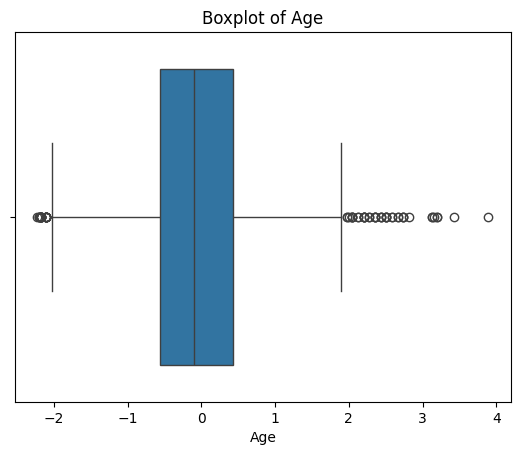

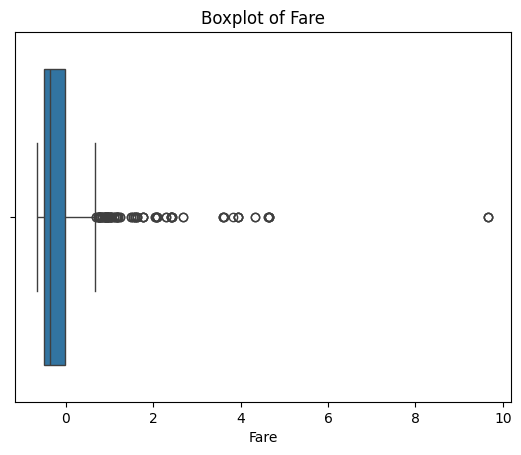

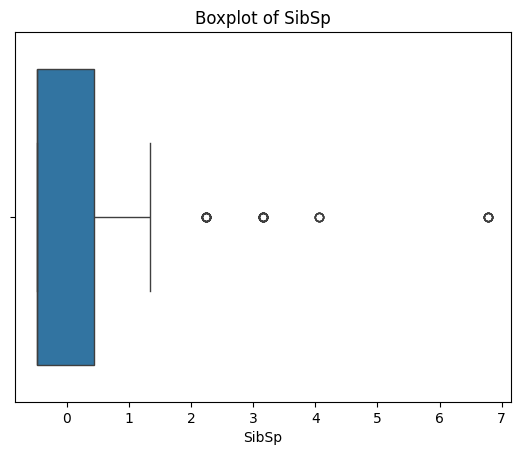

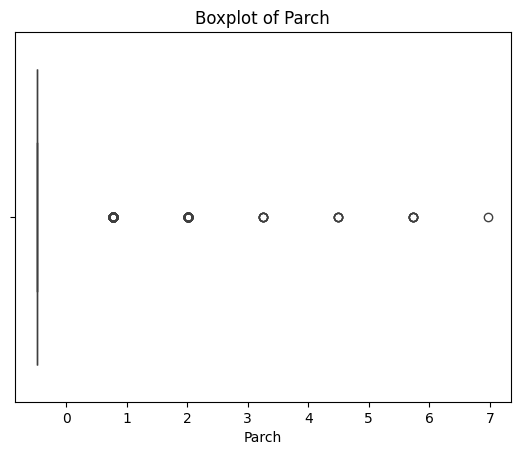

(577, 12)


In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# --- Visualize outliers using boxplots ---
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# --- Remove outliers using IQR method ---
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Final shape after removing outliers
print(df.shape)

Task 2


In [9]:
#1.generate summary statistics(mean,meadian,std,etc.).
df.describe()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
count,577.000000,577.000000,577.000000,577.000000,577.000000,577.000000,5.770000e+02,577.000000
mean,450.590988,0.299827,2.502600,0.247834,-0.004480,-0.293706,-4.736736e-01,-0.347884
std,259.568357,0.458579,0.733909,0.432129,0.657194,0.403796,2.777966e-16,0.253828
min,1.000000,0.000000,1.000000,0.000000,-1.872184,-0.474545,-4.736736e-01,-0.648422
25%,222.000000,0.000000,2.000000,0.000000,-0.412037,-0.474545,-4.736736e-01,-0.491874
50%,455.000000,0.000000,3.000000,0.000000,-0.104637,-0.474545,-4.736736e-01,-0.474005
75%,676.000000,1.000000,3.000000,0.000000,0.241187,-0.474545,-4.736736e-01,-0.329287
max,891.000000,1.000000,3.000000,1.000000,1.893459,1.340132,-4.736736e-01,0.583318


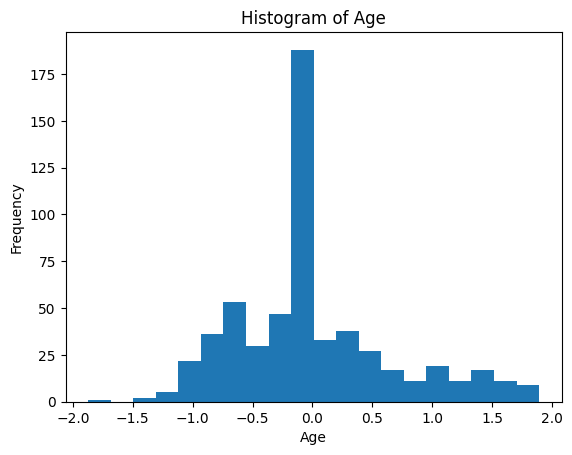

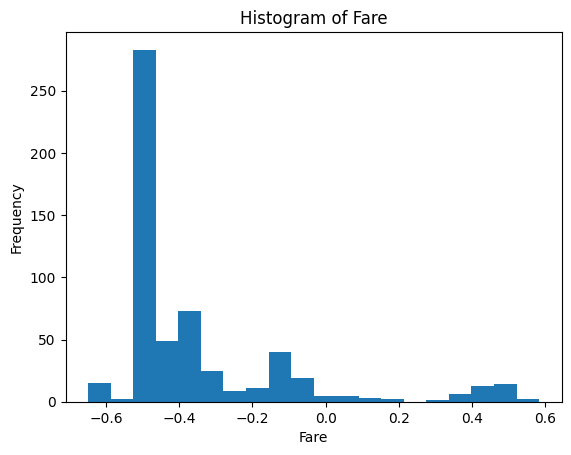

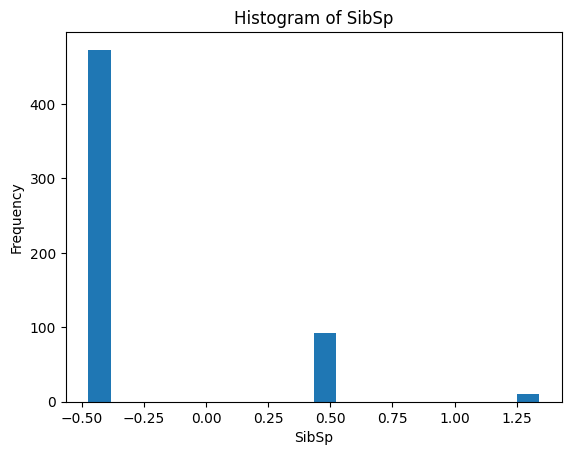

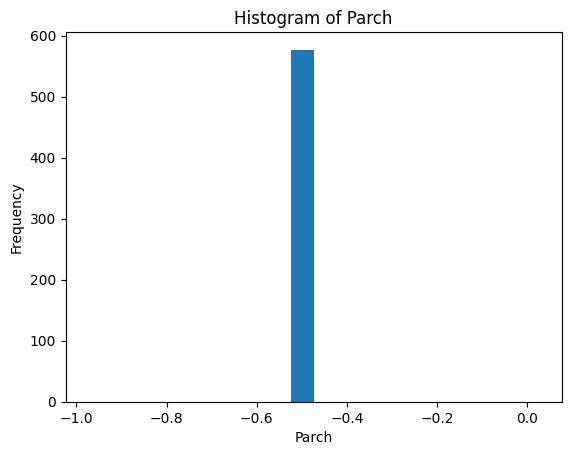

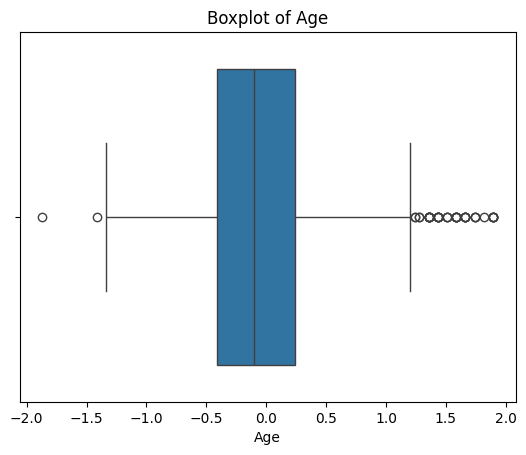

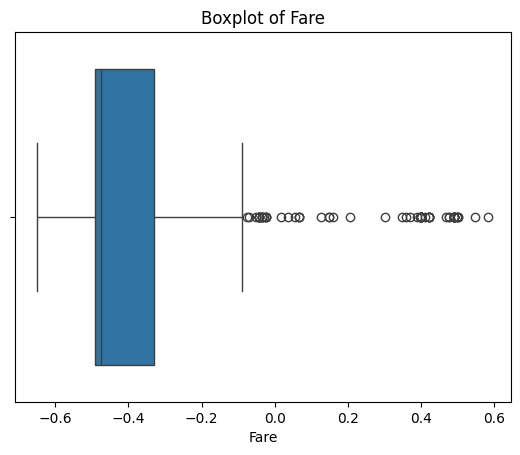

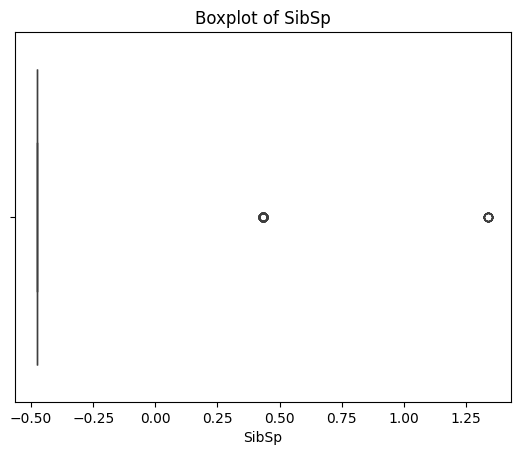

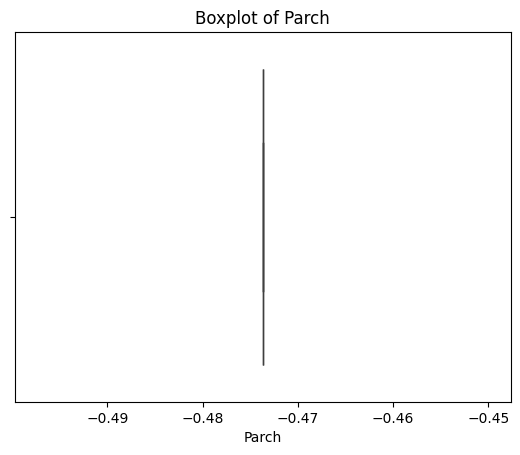

In [10]:
#create histogram and boxplots for numeric features
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
for col in num_cols:
    plt.figure()
    plt.hist(df[col], bins=20)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

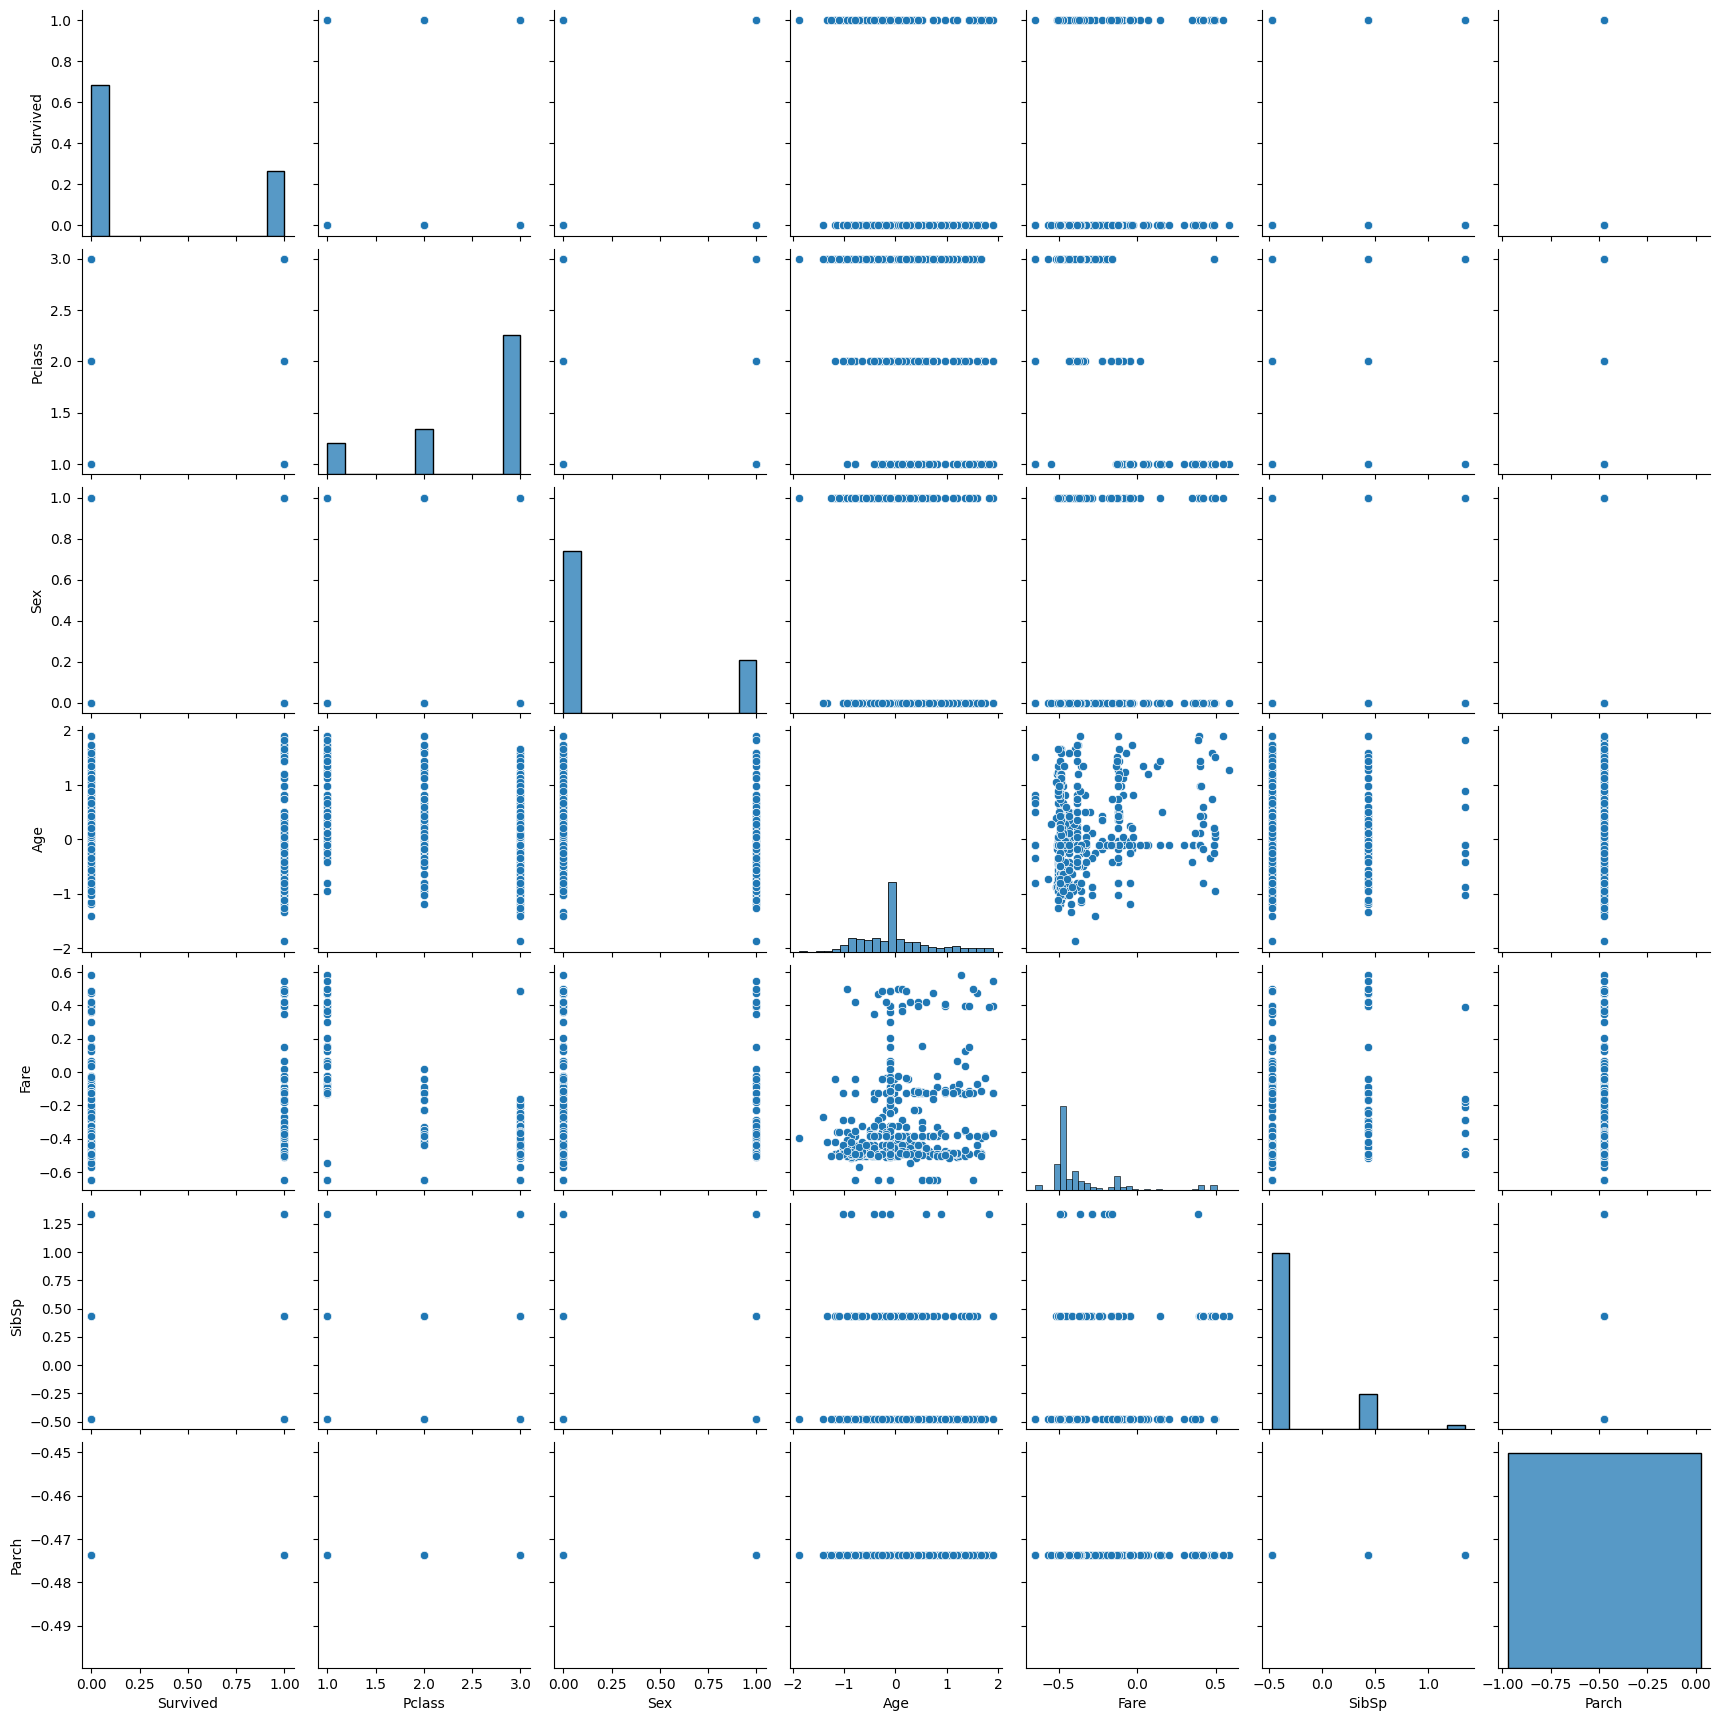

In [11]:
sns.pairplot(df[['Survived','Pclass','Sex','Age','Fare','SibSp','Parch']])
plt.show()

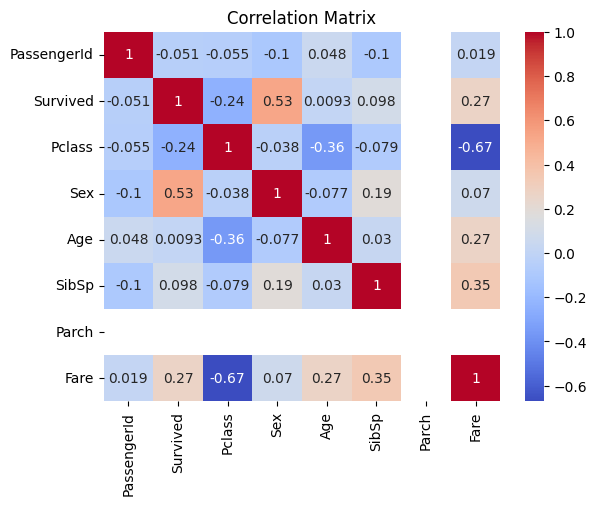

In [12]:
corr = df.select_dtypes(include=['number']).corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

#Task 3


In [17]:
from sklearn.model_selection import train_test_split

# Features (X) and Target (y)
X = df.drop(columns=['Survived','Name','Ticket'])   # input features
y = df['Survived']                  # target

# Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check shapes
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(461, 9) (116, 9)
(461,) (116,)


In [18]:
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train (fit) the model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# View first few predictions
print(y_pred[:5])

[0.33775364 0.6372853  0.63174727 0.15426674 0.12714592]


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

MAE: 0.26152133853713316
MSE: 0.12430995601058373
R² Score: 0.3370135679435534


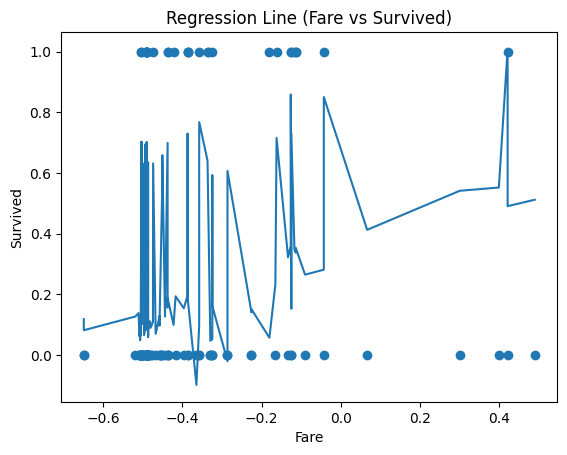

In [20]:

# Use one feature for visualization
X_vis = X_test['Fare']
y_vis = y_test

# Sort for smooth line
sorted_idx = X_vis.argsort()
X_vis_sorted = X_vis.iloc[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

# Plot
plt.scatter(X_vis, y_vis)          # actual
plt.plot(X_vis_sorted, y_pred_sorted)  # regression line

plt.xlabel("Fare")
plt.ylabel("Survived")
plt.title("Regression Line (Fare vs Survived)")
plt.show()

In [21]:
for col, coef in zip(X_train.columns, model.coef_):
    print(col, ":", coef)

print("Intercept:", model.intercept_)

PassengerId : -8.324738699066011e-06
Pclass : -0.05445120667880457
Sex : 0.537658372457071
Age : -0.021096037426781206
SibSp : -0.12215214996059762
Parch : -6.938893903907228e-16
Fare : 0.4235871713722566
Embarked_Q : -0.0063906809482933615
Embarked_S : -0.05822007109047972
Intercept: 0.46760026456241327
